In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as la
from matplotlib.collections import LineCollection

from tqdm import tqdm

from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala.lattice import cut_boundaries
from koala.graph_utils import make_dual, lloyd_relaxation, remove_trailing_edges
from koala import plotting as kplt
import matplotlib

matplotlib.rcParams.update({'font.size': 10, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern']})

In [2]:
def qwz_hamiltonian(lattice, u_vals, h_field = 0):
    if isinstance(u_vals, (int, float, complex)):
        u_vals = np.array([u_vals] * lattice.n_vertices)

    a_site_part = np.diag(u_vals+0j)
    b_site_part = -np.diag(u_vals+0j)

    ab_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)
    ba_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)

    p1 = lattice.vertices.positions[lattice.edges.indices[:, 0]]
    p2 = lattice.vertices.positions[lattice.edges.indices[:, 1]]   
    average_y = 0.5*(p1[:,1] + p2[:,1])
    change_x = p2[:,0] - p1[:,0]
    phases = -h_field * average_y * change_x * lattice.n_plaquettes

    for edge_index in range(lattice.n_edges):

        field_phase = 1j*phases[edge_index]*2*np.pi
        
        edge = lattice.edges.indices[edge_index]

        vec = lattice.edges.vectors[edge_index]
        angle = np.angle(vec[0] + 1j * vec[1])

        ab_link_part[edge[0], edge[1]] = 0.5j*np.exp(-1j*angle + field_phase)
        ba_link_part[edge[0], edge[1]] = 0.5j*np.exp(1j*angle + field_phase)
        a_site_part[edge[0], edge[1]] = 0.5*np.exp(field_phase)
        b_site_part[edge[0], edge[1]] = -0.5*np.exp(field_phase)

        # add conjugates
        ba_link_part[edge[1], edge[0]] = -0.5j*np.exp(1j*angle - field_phase)
        ab_link_part[edge[1], edge[0]] = -0.5j*np.exp(-1j*angle - field_phase)
        a_site_part[edge[1], edge[0]] = 0.5*np.exp(-field_phase)
        b_site_part[edge[1], edge[0]] = -0.5*np.exp(-field_phase)

    return np.block([
        [a_site_part, ab_link_part],
        [ba_link_part, b_site_part]
    ])

2000 3000 1000
1000 3000 2000
1987 2919 933
999 2868 1870


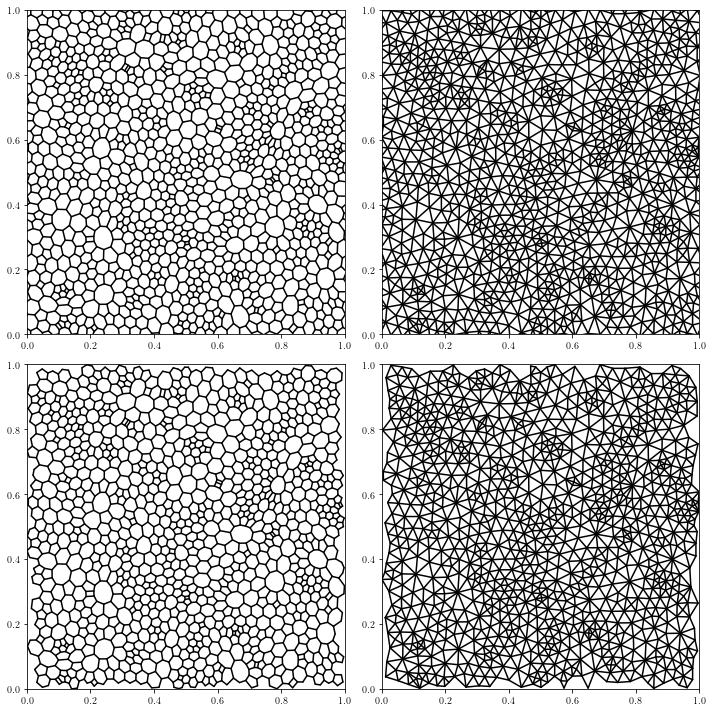

In [3]:
points = uniform(1000)
lattice = lloyd_relaxation(generate_lattice(points))
dual_lattice = make_dual(lattice)
lattice_strip = remove_trailing_edges(cut_boundaries(lattice, [True, True]))
dual_lattice_strip = remove_trailing_edges(cut_boundaries(dual_lattice, [True, True]))

fig, ax = plt.subplots(2,2,figsize=(10,10))
ax= ax.flatten()
plt.tight_layout()
kplt.plot_edges(lattice, ax = ax[0])
kplt.plot_edges(dual_lattice, ax=ax[1])
kplt.plot_edges(lattice_strip, ax = ax[2])
kplt.plot_edges(dual_lattice_strip, ax=ax[3])

all_lattices = [lattice, dual_lattice, lattice_strip, dual_lattice_strip]

for lat in all_lattices:
    print(lat.n_vertices, lat.n_edges, lat.n_plaquettes)

In [4]:


results = []
for i, eg_lattice in enumerate(all_lattices):

    if i in [0,2]:
        u_vals = np.linspace(-3.5,2.5, 100)
    else:
        u_vals = np.linspace(-4.5,2.5, 100)

    e_vals = []
    ipr_vals = []

    for u in tqdm(u_vals):
        ham = qwz_hamiltonian(eg_lattice, u)
        e, v = la.eigh(ham)

        e_vals.append(e)
        ipr = np.sum(np.abs(v**4), axis=0)
        ipr_vals.append(ipr)
        
    e_vals = np.array(e_vals)
    ipr_vals = np.array(ipr_vals)

    results.append((e_vals, ipr_vals))

100%|██████████| 100/100 [04:19<00:00,  2.59s/it]


In [5]:


def plot_line_with_colours(x, y, c, ax, norm = None, cmap='viridis'):
    if norm is None:
        norm = matplotlib.colors.Normalize(vmin=np.min(c), vmax=np.max(c))
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='viridis', norm=norm)
    lc.set_array(c)
    lc.set_linewidth(0.5)
    line = ax.add_collection(lc)


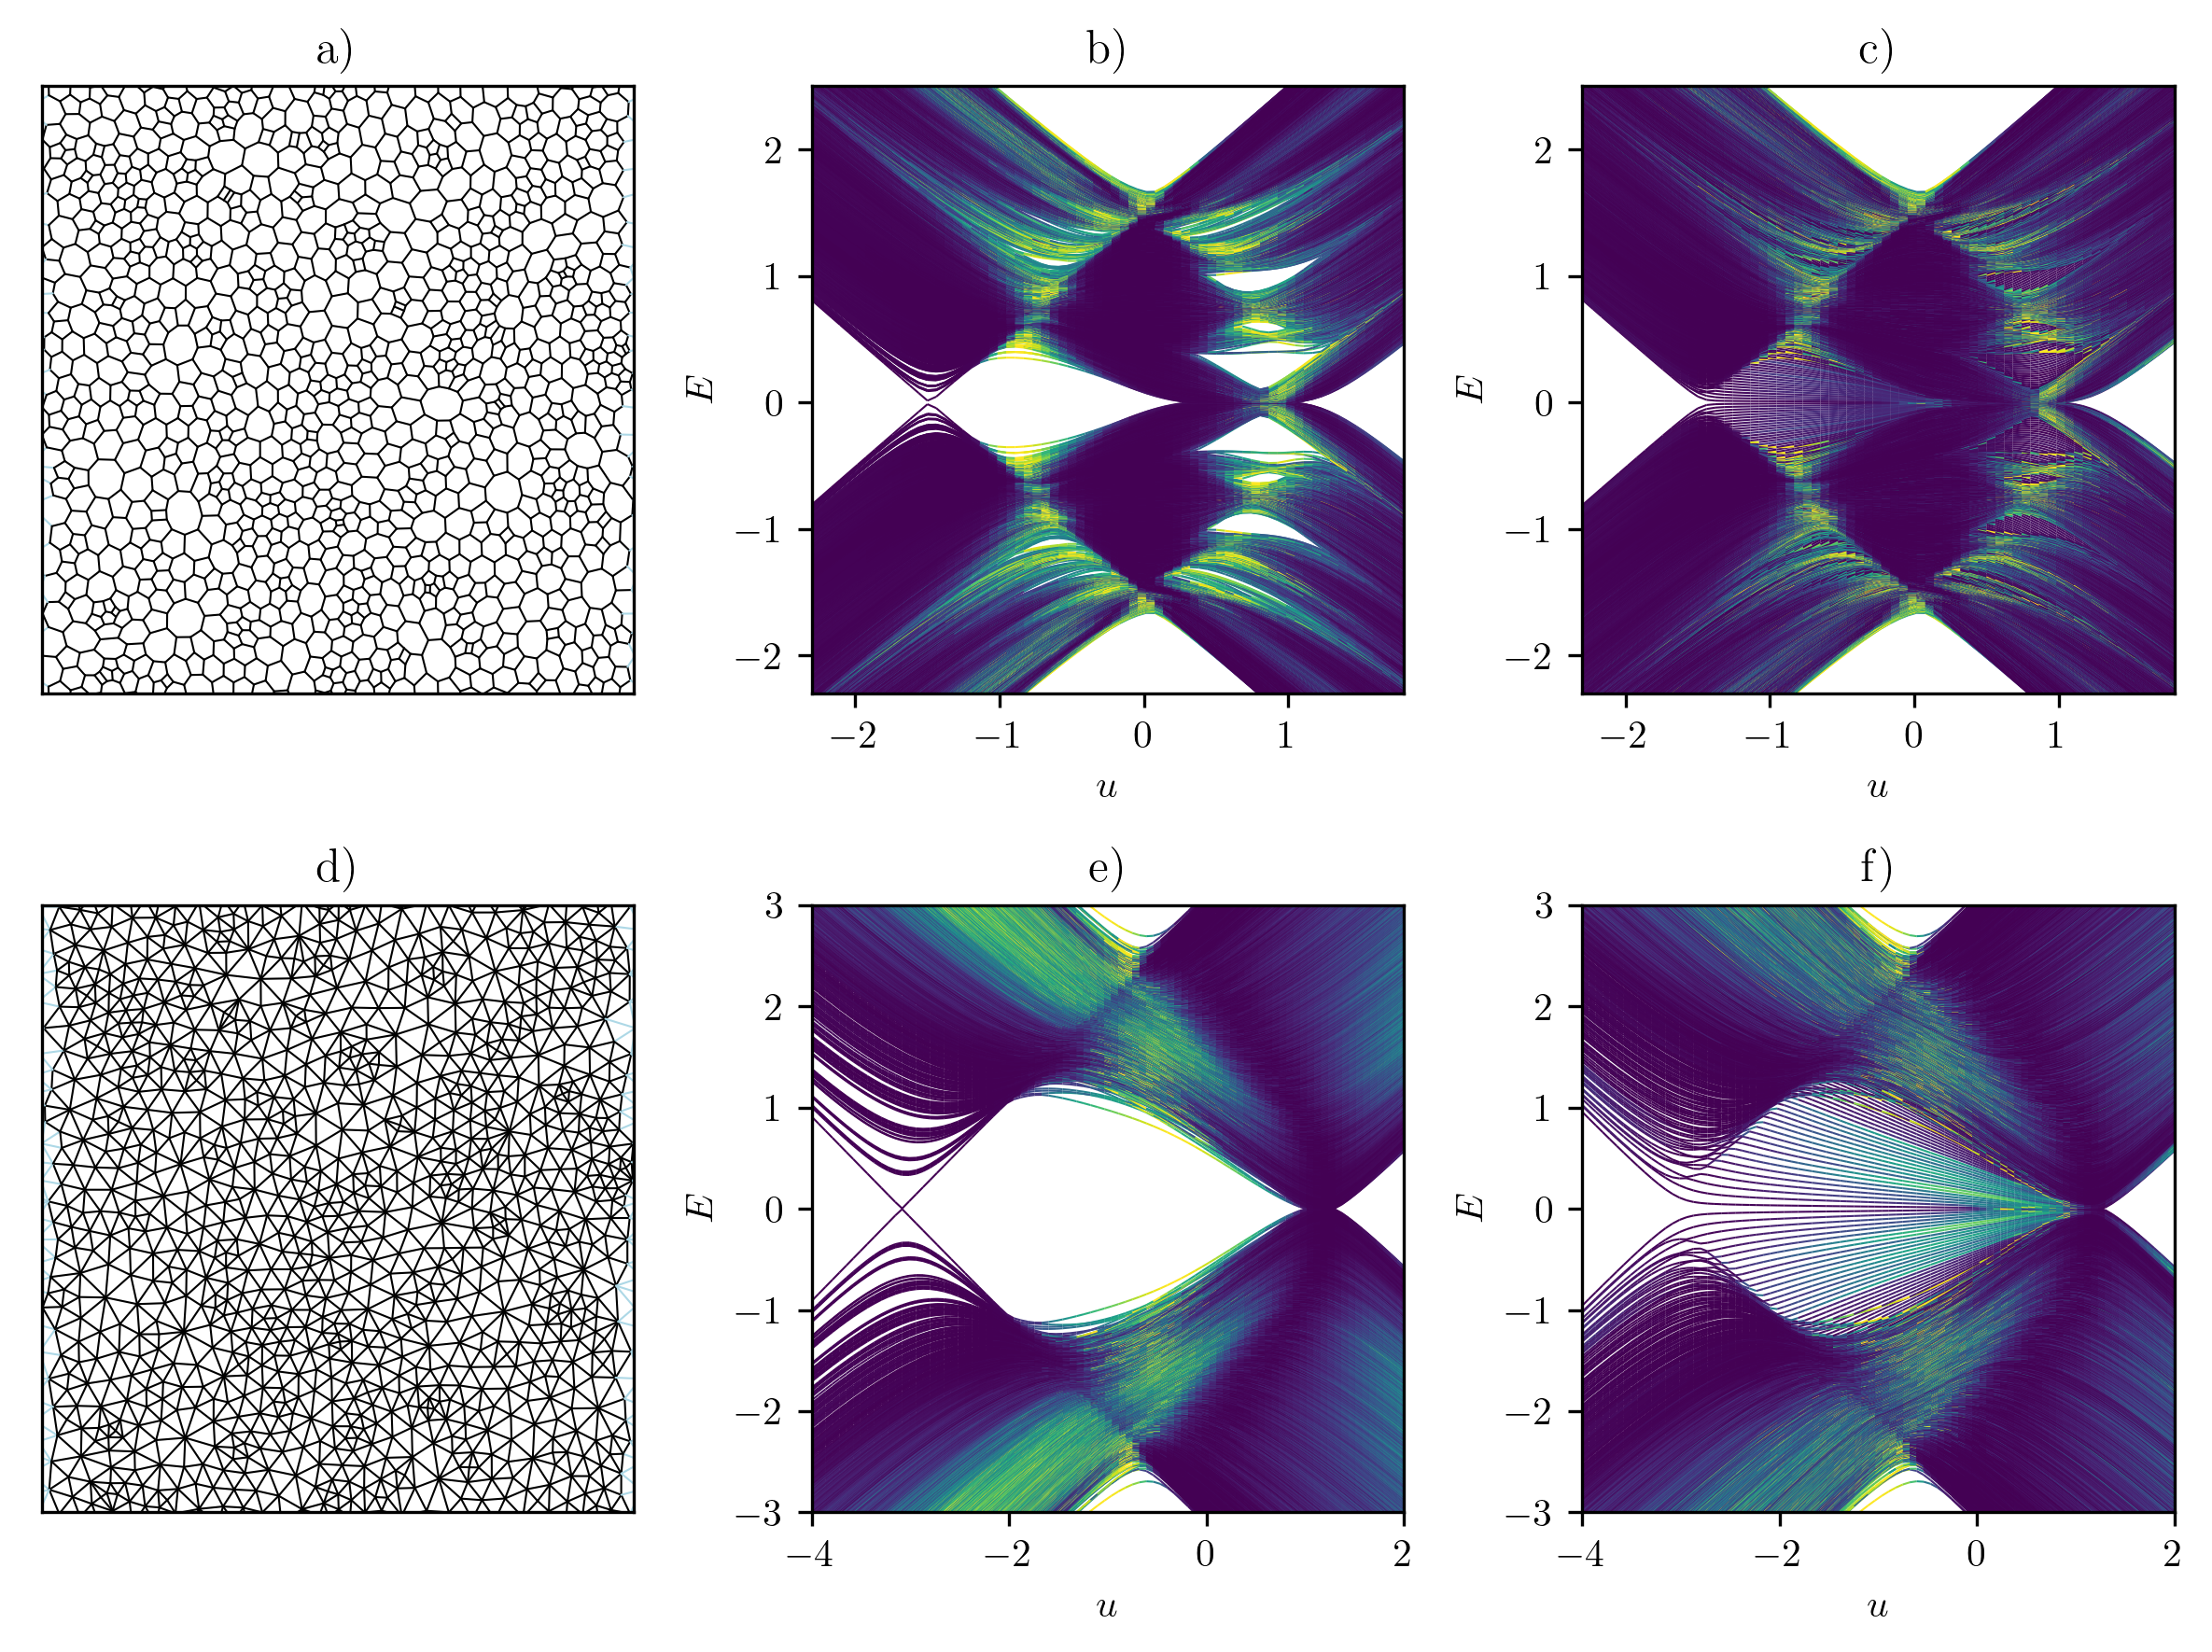

In [7]:
plt.rcParams["figure.autolayout"] = True

fig, ax = plt.subplots(2,3,figsize=(8,6), dpi = 300)
ax = ax.flatten()
kplt.plot_edges(lattice,labels = 1-(lattice.edges.crossing[:,0] == 0),color_scheme=['k', 'lightblue'], ax = ax[0], linewidth = 0.5)
kplt.plot_edges(dual_lattice,labels = 1-(dual_lattice.edges.crossing[:,0] == 0),color_scheme=['k', 'lightblue'], ax = ax[3], linewidth = 0.5)

for n, axis in enumerate([ax[1], ax[4], ax[2], ax[5]]):
    
    if n in [0,2]:
        u_vals = np.linspace(-3.5,2.5, 100)
        axis.set_xlim(-2.3,1.8)
        axis.set_ylim(-2.3,2.5)
    else:
        axis.set_xlim(-4,2)
        axis.set_ylim(-3,3)
        u_vals = np.linspace(-4.5,2.5, 100)

    energies = results[n][0]
    iprs = results[n][1]
    for i in range(energies.shape[1]):
        plot_line_with_colours(u_vals, energies[:,i], iprs[:,i], ax = axis, cmap = 'viridis')

    axis.set_xlabel(r'$u$')
    axis.set_ylabel(r'$E$')

for n,a in enumerate(ax):
    titles = np.array(['a)', 'b)', 'c)', 'd)', 'e)', 'f)'])
    a.set_title(titles[n])
# plt.tight_layout()

for a in [ax[0], ax[3]]:
    a.set_xticks([])
    a.set_yticks([])

plt.savefig('amorphous_qwz.pdf', bbox_inches='tight', pad_inches=0.0)
plt.savefig('amorphous_qwz.png', bbox_inches='tight', pad_inches=0.0, dpi = 300)

# print(lattice.edges.crossing[:,0])